# 02 · §7.2 Relational Order N and Normalization (H0, H2)

**H0 gate:** val mAP@R vs λg on the gate slice + triplet-only floor — accept if some λg clears the floor within noise. **H2:** normalization ablation. Plus the per-order characterization (quality vs N).

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))  # RKD/ on path
sys.path.insert(0, os.getcwd())
import analysis_utils as au
import pandas as pd
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
df = pd.read_csv('results.csv')

### H0 — λg viability gate (phase1)

floor val mAP@R = 0.0232263691723346
viable λg band (mean ≥ floor):


,lambda_g,median,mean,sem,n
0,0.0100,0.0280,0.0280,NaN,1


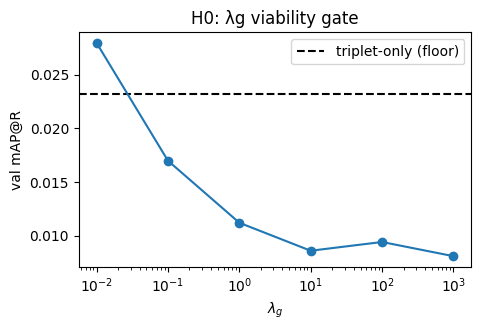

In [3]:
au.fig_h0_lambda(df);
g = df[(df.phase=='phase1')&(df.student=='graph-rkd')]
floor = df[(df.phase=='phase1')&(df.student=='triplet_only')]['val_mAP@R'].mean()
band = au.agg(g,['lambda_g'],'val_mAP@R')
print('floor val mAP@R =', floor)
print('viable λg band (mean ≥ floor):')
display(band[band['mean']>=floor])

### H2 — normalization ablation (phase2)

,norm,lambda_g,median,mean,sem,n
0,minibatch,0.0100,0.1019,0.1016,0.0157,6
3,none,0.0100,0.0605,0.0731,0.0210,6
6,per_graph,0.0100,0.1031,0.1019,0.0173,6


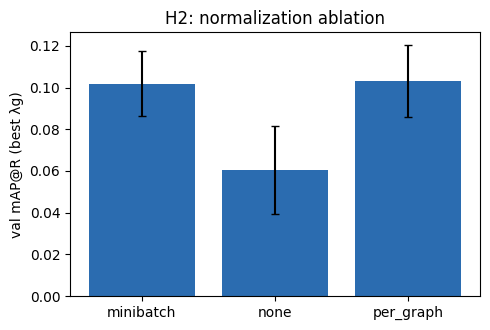

In [4]:
au.fig_h2_norm(df);
g2 = df[(df.phase=='phase2')&(df.student=='graph-rkd')]
per = au.agg(g2,['norm','lambda_g'],'val_mAP@R')
display(per.loc[per.groupby('norm')['mean'].idxmax()])

### Per-order quality (phase3): mAP@R vs N by descriptor

In [5]:
g3 = df[(df.phase=='phase3')&(df.student=='graph-rkd')]
if len(g3):
    display(au.agg(g3,['method','N'],'test_mAP@R'))
else:
    print('sem runs de phase3 ainda')

,method,N,median,mean,sem,n
0,mds,3.0000,0.0148,0.0171,0.0033,12
1,mds,4.0000,0.0134,0.0160,0.0033,12
2,mds,8.0000,0.0120,0.0147,0.0034,12
3,profile,3.0000,0.0133,0.0161,0.0034,12
4,profile,4.0000,0.0128,0.0155,0.0034,12
5,profile,8.0000,0.0113,0.0144,0.0033,12
